In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pulp
#for davis dataset 
#rabi=pd.read_csv(r"E:\network restructurong\data_set_new\crop\correct_crop_dacnet\Rabi_fertilizer_data_merged_dacnet_2009_2017_farmer_cost_davis_waer.csv")#davis data 
#for davis 
#kharif=pd.read_csv(r"E:\network restructurong\data_set_new\crop\correct_crop_dacnet\kharif_fertilizer_data_merged_dacnet_2009_2017_farmer_cost_davis_waer.csv")

#adding water in using hoestra data 
kharif=pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\fig2\code_final\kharif_waterdemand.csv")
rabi=pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\fig2\code_final\rabi_waterdemand.csv")
CoP= pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\cost_of_production.csv")
bnf_applied= pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\bnf\bnf_app.csv")

In [2]:
# Convert 'State' and 'Crop' column values to lowercase
CoP['State'] = CoP['State'].str.strip().str.lower()
CoP['Crop'] = CoP['Crop'].str.strip().str.lower()

# Now, the 'State' and 'Crop' columns in CoP DataFrame have all their values in lowercase
# Rename the columns in CoP to match kharif DataFrame for a consistent merge
CoP_renamed = CoP.rename(columns={"Crop": "crop", "State": "state", "CostofProduction_rs_Quintal": "Cost_of_Production_rs_Quintal"})
# Perform the merge
kharif = pd.merge(kharif, CoP_renamed, how='left', on=['state', 'Year', 'crop'])


In [3]:
import pandas as pd

# Sample data to illustrate the process. The actual data is not shown due to the format of the question.
# These dictionaries represent the mapping from atm['State'] to kharif['state'] based on the provided examples.
state_name_mapping = {
    'Andaman and Nicobar': 'andaman and nicobar',
    'Andhra Pradesh': 'andhra pradesh',
    'Arunachal Pradesh': 'arunachal pradesh',
    'Assam': 'assam',
    'Bihar': 'bihar',
    'Chandigarh': 'chandigarh',
    'Chhattisgarh': 'chhattisgarh',
    'Dadra and Nagar Haveli': 'dadra and nagar haveli',
    'Daman and Diu': 'the dadra and nagar haveli and daman and diu', # Assuming both to be mapped to the single entry in kharif
    'Delhi': 'delhi', # Not present in the provided kharif states list, but added for completeness
    'Goa': 'goa', # Not present in the provided list, but added for completeness
    'Gujarat': 'gujarat',
    'Haryana': 'haryana',
    'Himachal Pradesh': 'himachal pradesh',
    'Jammu and Kashmir': 'jammu and kashmir',
    'Jharkhand': 'jharkhand',
    'Karnataka': 'karnataka',
    'Kerala': 'kerala',
    'Lakshadweep': 'lakshadweep', # Not present, but added for completeness
    'Madhya Pradesh': 'madhya pradesh',
    'Maharashtra': 'maharashtra',
    'Manipur': 'manipur',
    'Meghalaya': 'meghalaya',
    'Mizoram': 'mizoram',
    'Nagaland': 'nagaland',
    'Orissa': 'odisha',
    'Puducherry': 'puducherry',
    'Punjab': 'punjab',
    'Rajasthan': 'rajasthan',
    'Sikkim': 'sikkim',
    'Tamil Nadu': 'tamil nadu',
    'Telangana': 'telangana',
    'Tripura': 'tripura',
    'Uttar Pradesh': 'uttar pradesh',
    'Uttaranchal': 'uttarakhand', # Mapped to 'uttarakhand' as per provided list
    'West Bengal': 'west bengal',
}

# Assume atm_df and kharif_df are the DataFrames for the 'atm' and 'kharif' datasets, respectively.
# This code will update the 'State' column in atm_df to match the 'state' values in kharif_df.

# Example atm_df DataFrame creation
# This is a placeholder and should be replaced with the actual atm DataFrame in practice.
atm_df= pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\fig2\code_final\atmospheric_depo_isimip_2a.csv")   # kg/ha

# Update 'State' in atm_df to match 'state' in kharif_df using the mapping
atm_df['State'] = atm_df['State'].map(state_name_mapping)
# Renaming 'State' in atm_df to 'state' to match kharif_df column name for a consistent merge
atm_df.rename(columns={'State': 'state'}, inplace=True)
# Assuming kharif_df exists, the merge operation would look like this:
# merged_df = pd.merge(kharif_df, atm_df, left_on='state', right_on='State')

# Displaying the updated atm_df for verification
atm_df


,Year,state,atm_depo
0,2009,andaman and nicobar,0.000000
1,2010,andaman and nicobar,0.000000
2,2011,andaman and nicobar,0.000000
3,2012,andaman and nicobar,0.000000
4,2013,andaman and nicobar,0.000000
...,...,...,...
427,2020,telangana,1.447027
428,2020,tripura,1.309994
429,2020,uttar pradesh,1.855148
430,2020,uttarakhand,1.651030


In [5]:
# Performing the merge based on 'state' and 'Year'
kharif = pd.merge(kharif, atm_df, on=['state', 'Year'], how='left')
kharif = pd.merge(kharif, bnf_applied, on=[ 'Year'], how='left')
#coeff from image mmodel 

image_coeff= pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\network restructurong\trial_analysis\image_coeff.csv")
image_coeff.rename(columns={'fN2O[% of Nsurplus]': 'fn2o', 'fNO3_leaching_to_GW[% of Nsurplus]': 'fno3'}, inplace=True)
image_coeff['State'] = image_coeff['State'].str.lower().str.strip()
image_coeff.rename(columns={'fN2O[% of Nsurplus]': 'fn2o', 'fNO3_leaching_to_GW[% of Nsurplus]': 'fno3'}, inplace=True)
image_coeff['fn2o'] = image_coeff['fn2o'] / 100    # as the value provided is in percentage 
image_coeff['fno3'] = image_coeff['fno3'] / 100

#image_coeff.rename(columns={'State':'state'}, inplace=True)
# Create a mapping dictionary from the abbreviated state names to the full state names
state_mapping = {
     'the dadra and nagar haveli and daman and diu':'dadra and nagar haveli',
    'andaman and nicobar islands':'andaman and nicobar'
}

# Use the 'replace' method to update the 'State' column in cwc_crop
image_coeff['State'] = image_coeff['State'].replace(state_mapping)
image_coeff.rename(columns={'State': 'state'}, inplace=True)


In [6]:
kharif = pd.merge(kharif, image_coeff, on=[ 'state'], how='left')


In [7]:

del kharif['Unnamed: 0']
del rabi['Unnamed: 0']
#manure nitrogen 
kharif['Manure (N_kg/ha)']=kharif['Manure (kg/ha)']*.005   #  https://agritech.tnau.ac.in/org_farm/orgfarm_manure.html
kharif['Manure (P_kg/ha)']=kharif['Manure (kg/ha)']*.002

rabi['Manure (N_kg/ha)']=rabi['Manure (kg/ha)']*.005
rabi['Manure (P_kg/ha)']=rabi['Manure (kg/ha)']*.002

# Ensure columns are numeric
kharif['N_applied(kg/ha)'] = pd.to_numeric(kharif['N_applied(kg/ha)'], errors='coerce')
kharif['Manure (N_kg/ha)'] = pd.to_numeric(kharif['Manure (N_kg/ha)'], errors='coerce')
kharif['P_applied(kg/ha)'] = pd.to_numeric(kharif['P_applied(kg/ha)'], errors='coerce')
kharif['Manure (P_kg/ha)'] = pd.to_numeric(kharif['Manure (P_kg/ha)'], errors='coerce')
kharif['Manure (N_kg/ha)'] = pd.to_numeric(kharif['Manure (N_kg/ha)'], errors='coerce')
kharif['CWR m3/ha'] = pd.to_numeric(kharif['CWR m3/ha'], errors='coerce')
kharif['CWU green m3/ha'] = pd.to_numeric(kharif['CWU green m3/ha'], errors='coerce')
kharif['CWU blue m3/ha'] = pd.to_numeric(kharif['CWU blue m3/ha'], errors='coerce')
# Replace 0 with np.nan using np.where
kharif['N_applied(kg/ha)'] = np.where(kharif['N_applied(kg/ha)'] == 0, np.nan, kharif['N_applied(kg/ha)'])
kharif['Manure (N_kg/ha)'] = np.where(kharif['Manure (N_kg/ha)'] == 0, np.nan, kharif['Manure (N_kg/ha)'])
kharif['P_applied(kg/ha)'] = np.where(kharif['P_applied(kg/ha)'] == 0, np.nan, kharif['P_applied(kg/ha)'])
kharif['Manure (P_kg/ha)'] = np.where(kharif['Manure (P_kg/ha)'] == 0, np.nan, kharif['Manure (P_kg/ha)'])
kharif['CWR m3/ha']  = np.where(kharif['CWR m3/ha'] == 0, np.nan, kharif['CWR m3/ha'])
kharif['CWU green m3/ha'] = np.where(kharif['CWU green m3/ha'] == 0, np.nan, kharif['CWU green m3/ha'])
kharif['CWU blue m3/ha'] = np.where(kharif['CWU blue m3/ha'] == 0, np.nan, kharif['CWU blue m3/ha'])

# Replace 'inf' with 'np.nan' in specified columns
kharif['N_applied(kg/ha)'] = kharif['N_applied(kg/ha)'].replace([np.inf, -np.inf], np.nan)
kharif['P_applied(kg/ha)'] = kharif['P_applied(kg/ha)'].replace([np.inf, -np.inf], np.nan)
kharif['K_applied(kg/ha)'] = kharif['K_applied(kg/ha)'].replace([np.inf, -np.inf], np.nan)

#calculating n app rate 
kharif['net_N_applied(kg/ha)']=kharif['N_applied(kg/ha)']+kharif['Manure (N_kg/ha)'] + kharif['atm_depo'] +kharif['BNF_kg_per_hec'] 

kharif['net_P_applied(kg/ha)']=kharif['P_applied(kg/ha)']+kharif['Manure (P_kg/ha)'] 



kharif_max=pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\network restructurong\data_set_new\crop\correct_crop_dacnet\kharif_max.csv")
del kharif_max['Unnamed: 0']



In [8]:
# IF FOLLOWING FAO FAOSTAT Domain Cropland Nutrient Budget Metadata, release November 2022
#https://www.fao.org/faostat/en/#data/ESB
# Define the nitrogen content dictionary (as provided previously)  # value in kg per kg product
crop_nitrogen_content = {
    'rice': .0129,
    'jowar': .0146,   # SORGHUM
    'bajra': .0204,
    'maize': .0124,
    'ragi': .0204
   # ,'wheat':.0209
}


crop_phosphorous_content = {
    'rice': .0028,
    'jowar': .0045,   # SORGHUM
    'bajra': .0042,
    'maize': .0034,
    'ragi': .0042
    #,'wheat':.0042
}

# Create the n_removed column by multiplying PRODUCTION (kg) by nitrogen content
kharif['n_removed_rate'] = kharif.apply(lambda row:crop_nitrogen_content.get(row['crop'], 0), axis=1)


# Create the p_removed column by multiplying PRODUCTION (kg) by nitrogen content
kharif['p_removed_rate'] = kharif.apply(lambda row:crop_phosphorous_content.get(row['crop'], 0), axis=1)
# Replace 0s with NaN in ''CWR m3/ha'' column
kharif['CWR m3/ha'].replace(0, float('nan'), inplace=True)


C:\Users\goyal\AppData\Local\Temp\5\ipykernel_7872\4228831115.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  kharif['CWR m3/ha'].replace(0, float('nan'), inplace=True)


In [9]:
#getting year specific data 
kharif_2017 = kharif[kharif['Year'].isin([2017])]

# Calculate the crop-specific average values for each nutrient
avg_nutrients = kharif_2017.groupby('crop')[['N_applied(kg/ha)', 'P_applied(kg/ha)', 'K_applied(kg/ha)', 'Manure (kg/ha)','Cost_of_Production_rs_Quintal']].transform('mean')

# Fill NaN values in kharif with the crop-specific average values
kharif_2017[['N_applied(kg/ha)', 'P_applied(kg/ha)', 'K_applied(kg/ha)', 'Manure (kg/ha)','Cost_of_Production_rs_Quintal']] = kharif_2017[['N_applied(kg/ha)', 'P_applied(kg/ha)', 'K_applied(kg/ha)', 'Manure (kg/ha)','Cost_of_Production_rs_Quintal']].fillna(avg_nutrients)

avg_wat=kharif_2017.groupby(['state','crop'])[['CWR m3/ha', 'CWU green m3/ha','CWU blue m3/ha']].transform('mean')
kharif_2017[['CWR m3/ha', 'CWU green m3/ha','CWU blue m3/ha']] = kharif_2017[['CWR m3/ha', 'CWU green m3/ha','CWU blue m3/ha']].fillna(avg_wat)


C:\Users\goyal\AppData\Local\Temp\5\ipykernel_7872\1332071418.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kharif_2017[['N_applied(kg/ha)', 'P_applied(kg/ha)', 'K_applied(kg/ha)', 'Manure (kg/ha)','Cost_of_Production_rs_Quintal']] = kharif_2017[['N_applied(kg/ha)', 'P_applied(kg/ha)', 'K_applied(kg/ha)', 'Manure (kg/ha)','Cost_of_Production_rs_Quintal']].fillna(avg_nutrients)
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_7872\1332071418.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kharif_2017

In [10]:
# Assuming rabi_2017 is your DataFrame
kharif_2017['Manure (N_kg/ha)'].fillna(0, inplace=True)
kharif_2017['Manure (P_kg/ha)'].fillna(0, inplace=True)

#calculating n app rate 
#calculating n app rate 
kharif_2017['net_N_applied(kg/ha)']=kharif_2017['N_applied(kg/ha)']+kharif_2017['Manure (N_kg/ha)'] + kharif_2017['atm_depo'] +kharif_2017['BNF_kg_per_hec'] 

kharif_2017['net_P_applied(kg/ha)']=kharif_2017['P_applied(kg/ha)']+kharif_2017['Manure (P_kg/ha)'] 


#finding historical area 
# Grouping the data by state, district, and crop and summing the area
historical_cereal_area = kharif.groupby(['state', 'district', 'crop'])['Area (Hectare)'].mean()

# Convert the grouped data to a dictionary
historical_cereal_area_dict = historical_cereal_area.to_dict()

#historiccally maximum area 
# Grouping the data by state and district and summing the area to find the maximum historical area
total_historical_area_district = kharif.groupby(['state', 'district','Year'])['Area (Hectare)'].sum()
max_historical_area_district = kharif.groupby(['state', 'district'])['Area (Hectare)'].mean()

# Convert the grouped data to a dictionary
max_historical_area_district_dict = max_historical_area_district.to_dict()

# Display the first few elements of the dictionary to verify
list(max_historical_area_district_dict.items())[:5]




C:\Users\goyal\AppData\Local\Temp\5\ipykernel_7872\3883408602.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  kharif_2017['Manure (N_kg/ha)'].fillna(0, inplace=True)
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_7872\3883408602.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kharif_2017['Manure (N_kg/ha)'].fillna(0, inplace=True)
C:\Us

[(('andaman and nicobar', 'nicobars'), 3.247),
 (('andaman and nicobar', 'north and middle andaman'), 6199.9169999999995),
 (('andaman and nicobar', 'south andamans'), 415.741),
 (('andhra pradesh', 'adilabad'), 30125.416666666668),
 (('andhra pradesh', 'anantapur'), 12385.51923076923)]

In [20]:
df = kharif_2017
#del df['Unnamed: 0']
# Renaming the column
df.rename(columns={'district': 'District'}, inplace=True)
df.rename(columns={'state': 'State'}, inplace=True)
df.rename(columns={'crop': 'Crop'}, inplace=True)


#finding maximum area 
kharif_max.rename(columns={'district': 'District'}, inplace=True)
kharif_max.rename(columns={'state': 'State'}, inplace=True)
kharif_max.rename(columns={'crop': 'Crop'}, inplace=True)
kharif_max['Crop'] = kharif_max['Crop'].str.lower().str.strip()




 #  only kharif crop 
# Step 1: Filter the DataFrame
selected_crops = ['bajra', 'jowar', 'ragi', 'rice'
                  ,'maize'
                  ]
df = df[df['Crop'].isin(selected_crops)]
kharif_max = kharif_max[kharif_max['Crop'].isin(selected_crops)]


# Step 2: Create a dictionary for maximum area constraints
max_area_constraints = kharif_max.set_index(['State','District', 'Crop'])['Area (Hectare)'].to_dict()

# Convert to lowercase and strip whitespace
df['District'] = df['District'].str.lower().str.strip()
df['State'] = df['State'].str.lower().str.strip()
df['Crop'] = df['Crop'].str.lower().str.strip()

#fillin nan value in applied n with national avg 
#filling the nan values in the n application rate with state and crop avg value 
# Compute the average for 'N_applied(kg/ha)' grouped by 'State' and 'Crop'
avg_N_applied = df.groupby(['Crop'])['net_N_applied(kg/ha)'].transform('mean')
global_avg=kharif.groupby(['crop'])['net_N_applied(kg/ha)'].transform('mean')
# Replace NaN values in 'net_N_applied(kg/ha)' with the computed average
df['net_N_applied(kg/ha)'].fillna(avg_N_applied, inplace=True)
if df['net_N_applied(kg/ha)'].isnull().any():
    df['net_N_applied(kg/ha)'].fillna(global_avg, inplace=True)  # Fallback to global average if needed

#fillin nan value in applied p with national avg 
avg_P_applied = df.groupby(['Crop'])['net_P_applied(kg/ha)'].transform('mean')
global_avg_P=kharif.groupby(['crop'])['net_P_applied(kg/ha)'].transform('mean')
# Replace NaN values in 'net_P_applied(kg/ha)' with the computed average
df['net_P_applied(kg/ha)'].fillna(avg_P_applied, inplace=True)
if df['net_P_applied(kg/ha)'].isnull().any():
    df['net_P_applied(kg/ha)'].fillna(global_avg_P, inplace=True)  # Fallback to global average if needed


#filling cost of cultivattion with avg vallue 
# Step 1
avg_cost_cult = df.groupby('Crop')['Cost_of_Production_rs_Quintal'].transform('mean')

# Step 2
df['Cost_of_Production_rs_Quintal'].fillna(avg_cost_cult, inplace=True)

# Step 3
if df['Cost_of_Production_rs_Quintal'].isnull().any():
    print("NaN values present after local crop average fill")

    # Step 4
    global_avg_cost_cult = kharif.groupby('crop')['Cost_of_Production_rs_Quintal'].transform('mean')

    # Step 5
    df['Cost_of_Production_rs_Quintal'].fillna(global_avg_cost_cult, inplace=True)

# Step 6
if df['Cost_of_Production_rs_Quintal'].isnull().any():
    print("NaN values present after global average fill")
else:
    print("All NaN values filled")
    
# replace all occurrences of -1 in the 'AREA (1000 ha)' and 'PRODUCTION (1000 tons)' columns with zero   which signifies missing values 
df['Area (Hectare)'] = df['Area (Hectare)'].replace(-1, 0)
df['Production (Tonnes)'] = df['Production (Tonnes)'].replace(-1, 0)
df['YIELD (Kg per ha)'] = 1000*df['Yield (Tonnes/Hectare)'].replace(-1, 0)
#compute avg water requiremment 
avg_applied_CWR = df.groupby(['Crop'])['CWR m3/ha'].transform('mean')
global_avg_cwr=kharif.groupby(['crop'])['CWR m3/ha'].transform('mean')
# Replace NaN values in 'CWR m3/ha' with the computed average
df['CWR m3/ha'].fillna(avg_applied_CWR, inplace=True)
if df['CWR m3/ha'].isnull().any():
    df['CWR m3/ha'].fillna(global_avg_cwr, inplace=True)  # Fallback to global average if needed

df['CWR m3/ha'] = df['CWR m3/ha'].fillna(0)

#setting yield 
yield_data = df.set_index(['State','District', 'Crop'])['YIELD (Kg per ha)'].to_dict()

# Calorie data (converted to per tonne)  
# in kcal 
#calorie_per_100g = {
    #'ragi': 328,
    #'bajra': 361,
    #'rice': 345,
    #'jowar': 349,
    #'wheat': 346,
    #'maize': 342
    #,'barley': 352
#}
calorie_per_100g = {
    'ragi': 321,
    'bajra': 348,
    'rice': 356,
    'jowar': 334,
    'wheat': 322
    ,'maize': 342
    #,'barley': 352
}
#calorie_per_tonne = {cereal: value * 10000 for cereal, value in calorie_per_100g.items()}   # in 1000TONNE   chnage  calorie_per_tonneto  calorie_per_kg
calorie_per_kg = {cereal: value * 10 for cereal, value in calorie_per_100g.items()}   # in kg   chnage  calorie_per_tonneto  calorie_per_kg


#aghg Per-Area Total (Mg CO2e ha-1) 2017
# Dictionary mapping crop names to their corresponding values   
crop_co2e = { 
    'bajra': 0.098603856,
    'ragi': 0.098603856,
    'rice': 8.213913103,
    'jowar': 0.154967254,
    'wheat': 0.729809876,
    'maize': 0.889859651
}

AGHG_per_ha = {cereal: value for cereal, value in crop_co2e.items()}   # in (Mg CO2e ha-1)


# Calculate Total Calorie Supply for Each District-Cereal Combination
#df['Calorie Supply (per tonne)'] = df['Crop'].map(calorie_per_tonne)
df['Calorie Supply (per KG)'] = df['Crop'].map(calorie_per_kg)   # crop wise calorie mapping
#total aghg produced in india 
df['AGHG_produced (per ha)'] = df['Crop'].map(AGHG_per_ha)   # crop wise aghg mapping (Mg CO2e ha-1) 2017

df['Total Calorie Supply'] =1000*df['Production (Tonnes)'] * df['Calorie Supply (per KG)']   # IN KG
df['Total Farmer Cost'] = 10*df['Production (Tonnes)'] * df['Cost_of_Production_rs_Quintal']  # as area is in 1000ha    

#calculate total selling price for each district-cereal combination
#data['MSP Supply (per tonne)'] = data['Crop'].map(msp_per_tonne)
df['Total MSP Supply'] = 10*df['Production (Tonnes)'] * df['MSP_RsperQntl']  # tonne to qut factor is 10 10000 to convert 1000ton
df['Total initial profit']=df['Total MSP Supply'] - df['Total Farmer Cost']
#data.head(4)

# Extract Data into Dictionaries
districts = df['District'].unique().tolist()
states = df['State'].unique().tolist()
cereals = df['Crop'].unique().tolist()


#current_area = df.set_index('District')['AREA (1000 ha)'].to_dict()  # this was wrong as it was giving only last district area 
current_area = df.groupby(['State','District'])['Area (Hectare)'].sum().to_dict() # this gives sum of all the area of all crops in the district

#nitrogen_rate = data.groupby('Crop')['N_applied(kg/ha)'].mean().to_dict()   #need to change 
#in this synthetic + manure + atm+bnf applied value is to be used   application rate 
nitrogen_rate = df.set_index(['State','District', 'Crop'])['net_N_applied(kg/ha)'].to_dict()
nitrogen_removal_rate_perkg=  df.set_index(['State','District', 'Crop'])['n_removed_rate'].to_dict()
#NITROGEN LEACH 
nitrogen_leach_rate_perkg=df.set_index(['State','District', 'Crop'])['fno3'].to_dict()   # this is to be multipkied by the surplus value that we are getting for each disstrict as we are assuming the leaching is same 
#nitrogen emission 
nitrogen_emission_rate_perkg=df.set_index(['State','District', 'Crop'])['fn2o'].to_dict()
#AGHG_rate                                       #Mg CO2e ha-1
#phosphorous_rate = data.groupby('Crop')['N_applied(kg/ha)'].mean().to_dict()   #need to change 
#in this synthetic + manure + atm+bnf applied value is to be used   application rate 
P_rate = df.set_index(['State','District', 'Crop'])['net_P_applied(kg/ha)'].to_dict()
P_removal_rate_perkg=  df.set_index(['State','District', 'Crop'])['p_removed_rate'].to_dict()

#water requirement 
water_rate = df.set_index(['State','District', 'Crop'])['CWR m3/ha'].to_dict()

#calories_per_area = data.set_index(['District', 'Crop'])['Calorie Supply (per tonne)'].to_dict()   # need tocheck as it should be calorie per unit production
calories_per_prod = df.set_index(['State','District', 'Crop'])['Calorie Supply (per KG)'].to_dict()   # this is to be multiplieed by the production value 
#aghg
AGHG_per_ha = df.set_index(['State','District', 'Crop'])['AGHG_produced (per ha)'].to_dict()   # this is to be multiplieed by the area  # crop wise aghg mapping (Mg CO2e ha-1) 2017 

district_to_state = df.set_index('District')['State'].to_dict()

cost_per_area = df.set_index(['State','District', 'Crop'])['Cost_of_Production_rs_Quintal'].to_dict()   # in ha   # cosyt of cultivation

MSP_per_prod = df.set_index(['State','District', 'Crop'])['MSP_RsperQntl'].to_dict()   # in quintal
current_cereal_area = {}
for index, row in df.iterrows():
    current_cereal_area[row['State'],row['District'], row['Crop']] = row['Area (Hectare)']    # in ha

current_cereal_prod = {}
for index, row in df.iterrows():
    current_cereal_prod[row['State'],row['District'], row['Crop']] = row['Production (Tonnes)']


#current applied nitrogen value 
original_nitrogen_values = [current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print(original_nitrogen_values)  # This will give the individual nitrogen applications for each district-cereal combo
original_N_surplus_value=[(current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0))  for s in states for d in districts for c in cereals]
#total n applied 
original_total_nitrogen = sum(original_nitrogen_values) # nitrogen applied 
original_N_surplus=  sum(original_N_surplus_value)  # surplus kg
#nitrogen leach 
origina_N_leach_value=[nitrogen_leach_rate_perkg.get((s,d, c), 0)*((current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0)))  for s in states for d in districts for c in cereals]
original_N_leach=  sum(origina_N_leach_value)  # leach kg

original_N_emission_value= [nitrogen_emission_rate_perkg.get((s,d, c), 0)*((current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0)))  for s in states for d in districts for c in cereals]
original_N_emission=  sum(original_N_emission_value)  # leach kg
print("Original Total Nitrogen Applied kg:", original_total_nitrogen)
print("Original Total Nitrogen Surplus generated kg:", original_N_surplus)
print("Original Total Nitrogen leach generated kg:", original_N_leach)
print("Original Total Nitrogen emission generated kg:", original_N_emission)


#current applied phosphorous value 
original_P_values = [current_cereal_area.get((s,d, c), 0) * P_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print(original_p_values)  # This will give the individual p applications for each district-cereal combo
original_P_surplus_value=[(current_cereal_area.get((s,d, c), 0) * P_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*P_removal_rate_perkg.get((s,d, c), 0))  for s in states for d in districts for c in cereals]
#total p applied 
original_total_P = sum(original_P_values) # nitrogen applied 
original_P_surplus=  sum(original_P_surplus_value)  # surplus kg

print("Original Total phosphorus Applied kg:", original_total_P)
print("Original Total phosphorus Surplus generated kg:", original_P_surplus)


#originall water required
original_water_values = [current_cereal_area.get((s,d, c), 0) * water_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print total water required 
#total n applied 
original_total_water = sum(original_water_values)
print("Original Total water Applied:", original_total_water)
prob = pulp.LpProblem("OptimizeCerealArea", pulp.LpMinimize)
    # Decision Variables
x = pulp.LpVariable.dicts("Area (Hectare)", (states,districts,cereals), 0, None, pulp.LpContinuous)  # this is in ha
# Objective Function - Adjusted to use district & crop specific nitrogen rates
#for n applied 
#prob += pulp.lpSum([x[s][d][c]* nitrogen_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals])  # as area is in ha
#fornsurplus
#prob += pulp.lpSum([x[s][d][c]*(nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0) * nitrogen_removal_rate_perkg.get((s, d, c), 0))) for s in states for d in districts for c in cereals])   # for minimizing n surplus
#for p surplus 
#prob += pulp.lpSum([x[s][d][c]*(P_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0) * P_removal_rate_perkg.get((s, d, c), 0))) for s in states for d in districts for c in cereals])   # for minimizing n surplus
#minimizing water demand 
prob += pulp.lpSum([x[s][d][c]* water_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals])  # as area is in ha

#print(prob)
# Constraints
# Cropped Area Constraints    net area in the district within a state should remain same 
for s in states:
    for d in districts:
        prob += pulp.lpSum([x[s][d][c] for c in cereals]) == current_area.get((s,d), 0)

# adding historical area as a contrain where maximum achivable area is that od historically present 

# Step 3: Add the new constraints to your model
for s in states:
    for d in districts:
        for c in cereals:
            if c in max_area_constraints:
                prob += x[s][d][c] <= max_area_constraints[c]

# Existing Cereal Constraints   
# Replacement should happen when only crop is present 
#for s in states:
#    for d in districts:
#        for c in cereals:
#            if current_cereal_area.get((s,d,c), 0) == 0:
#                prob += x[s][d][c] == 0
#The constraint x[s][d][c] == 0: This is forcing the decision variable to be zero if the specific cereal was not originally planted in that district of that state, essentially saying 
#"if we didn't plant this cereal here before, we're not going to start now."

#instead of this we have to use historically present area 
for s in states:
    for d in districts:
        for c in cereals:
            if historical_cereal_area.get((s, d, c), 0) == 0:
                prob += x[s][d][c] == 0



# State Calorie Supply Constraints - State-wise calorie generated should remain the same
initial_state_calories = df.groupby('State')['Total Calorie Supply'].sum().to_dict()
for s in states:
    prob += pulp.lpSum(
        [x[s][d][c] * yield_data.get((s, d, c), 0) * calories_per_prod.get((s, d, c), 0) 
         for d in districts for c in cereals]
    ) >= initial_state_calories[s]


# Adding  farmers msp selling profit  Constraint
#initial_state_msp = df.groupby('State')['Total MSP Supply'].sum().to_dict()    # this is cost of cultivation of crop 
#for s in states:
#    prob += pulp.lpSum([x[s][d][c]* yield_data.get((s, d, c), 0)* MSP_per_prod.get((s,d, c), 0) for d in districts if district_to_state.get(d) == s for c in cereals]) >= initial_state_msp[s]


# Adding  Farmer Cost of production  Constraint
#initial_state_costs = df.groupby('State')['Total Farmer Cost'].sum().to_dict()    # this is cost of cultivation of crop 
#for s in states:
#    prob += pulp.lpSum([x[s][d][c]* cost_per_area.get((s,d, c), 0) for d in districts if district_to_state.get(d) == s for c in cereals]) <= initial_state_costs[s]

# Adding  Farmer profit of production  Constraint
#df['Total initial profit']
initial_state_profit = df.groupby('State')['Total initial profit'].sum().to_dict()    # this is cost of cultivation of crop 
for s in states:
    prob += pulp.lpSum([(x[s][d][c]* yield_data.get((s, d, c), 0)* 0.01*MSP_per_prod.get((s,d, c), 0))-(x[s][d][c]*yield_data.get((s, d, c), 0)* 0.01* cost_per_area.get((s,d, c), 0)) for d in districts if district_to_state.get(d) == s for c in cereals]) >= initial_state_profit[s]


#adding constrain that original maize should not increase 
#initial_maize_area_by_state = df[df['Crop'] == 'maize'].groupby('State')['Area (Hectare)'].sum().to_dict()

#for s in states:
#    prob += pulp.lpSum([x[s][d]['maize'] for d in districts if district_to_state.get(d) == s]) == initial_maize_area_by_state.get(s, 0)

  

# Set the path for glpsol in GLPK_CMD
#solver = pulp.GLPK_CMD(path=r"C:\Users\\shekh\\anaconda3\\envs\\opt_agri\\Library\\bin\\glpsol.exe")
#"C:\Users\shekh\anaconda3\envs\opt_agri\Library\bin\glpsol.exe"
solver = pulp.PULP_CBC_CMD()
#solver = pulp.GLPK_CMD()
prob.solve(solver)
#solver = pulp.GLPK_CMD()
#prob.solve(solver)

#optimized_total_nitrogen = pulp.value(prob.objective)
#optimal_water_saving = pulp.value(prob.objective)
optimal_water_= [(pulp.value(x[s][d][c]))* water_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals] 
optimal_water_saving = sum(optimal_water_)

#print("optimized_total_nitrogen", optimized_total_nitrogen)
print("optimized_total_water", optimal_water_saving)

print("Status:", pulp.LpStatus[prob.status])
#percentage change
percentage_change_w = ((original_total_water-optimal_water_saving) / original_total_water) * 100
print("% reduction in net water applied :", percentage_change_w)


#current applied nitrogen value 
original_nitrogen_values = [current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print(original_nitrogen_values)  # This will give the individual nitrogen applications for each district-cereal combo
original_N_surplus_value=[(current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0))  for s in states for d in districts for c in cereals]
#total n applied 
original_total_nitrogen = sum(original_nitrogen_values) # nitrogen applied 
original_N_surplus=  sum(original_N_surplus_value)  # surplus kg

print("Original Total Nitrogen Applied kg:", original_total_nitrogen)
print("Original Total Nitrogen Surplus generated kg:", original_N_surplus)


#current applied phosphorous value 
original_P_values = [current_cereal_area.get((s,d, c), 0) * P_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print(original_p_values)  # This will give the individual p applications for each district-cereal combo
original_P_surplus_value=[(current_cereal_area.get((s,d, c), 0) * P_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*P_removal_rate_perkg.get((s,d, c), 0))  for s in states for d in districts for c in cereals]
#total p applied 
original_total_P = sum(original_P_values) # nitrogen applied 
original_P_surplus=  sum(original_P_surplus_value)  # surplus kg

print("Original Total phosphorus Applied kg:", original_total_P)
print("Original Total phosphorus Surplus generated kg:", original_P_surplus)


#originall water required
original_water_values = [current_cereal_area.get((s,d, c), 0) * water_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print total water required 
#total n applied 
original_total_water = sum(original_water_values)
print("Original Total water Applied:", original_total_water)

#optimized water 
#optimal_water= sum(optimal_water_saving)
#originall Calorie generated in kg 
original_calorie_values = [1000*current_cereal_prod.get((s,d, c), 0) * calories_per_prod.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#total calorie applied 
original_total_calorie = sum(original_calorie_values)
print(" original_total_calorie:", original_total_calorie)



#originall msp  generated in kg 
original_msp_values = [10*current_cereal_prod.get((s,d, c), 0) * MSP_per_prod.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print total water required 
#total n applied 
original_total_msp = sum(original_msp_values)
print(" original_total_msp:", original_total_msp)


#total profit
#original_profit_values = [((10*current_cereal_prod.get((s,d, c), 0) * MSP_per_prod.get((s,d, c), 0))-(10*current_cereal_prod.get((s,d, c), 0) * cost_per_area.get((s,d, c), 0))) for s in states for d in districts for c in cereals]  #area is in ha
#original_total_profit = sum(original_profit_values)
#print(" original_total_profit:", original_total_profit)



#optimized valued 
#FOR NITROGEN 
optimized_total_nitrogen_surplus = sum((pulp.value(x[s][d][c]))*(nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0)))
                       for s in states for d in districts for c in cereals)
print("optimized total nitrogen surplus", optimized_total_nitrogen_surplus)
print("Status:", pulp.LpStatus[prob.status])

#for nitrogen applied 
optimized_total_P_F_applied=sum((pulp.value(x[s][d][c])) * P_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals)

#for Phosphorus surplus 
optimized_total_P_surplus =sum((pulp.value(x[s][d][c]))*(P_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0)*P_removal_rate_perkg.get((s,d, c), 0)))
                       for s in states for d in districts for c in cereals)
print("optimized total Phosphorus surplus", optimized_total_P_surplus)
print("Status:", pulp.LpStatus[prob.status])


#percentage change for p surplus
percentage_change_p = ((original_P_surplus-optimized_total_P_surplus) / original_P_surplus) * 100
print("% reduction in net p surplus :", percentage_change_p)

#percentage change for p applied
# p fert_applied
optimized_total_P_F_applied=sum((pulp.value(x[s][d][c])) * P_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals)
print("optimized total Phosphorus applied", optimized_total_P_F_applied)
percentage_change_p_applied = ((original_total_P-optimized_total_P_F_applied) / original_total_P) * 100
print("% reduction in net p applied :", percentage_change_p_applied)

#percentage change nitrogen surplus 
percentage_change_N = ((original_N_surplus-optimized_total_nitrogen_surplus) / original_N_surplus) * 100
print("% reduction in net nitrogen surplus :", percentage_change_N)

#percentage change for N applied
# N fert_applied
optimized_total_N_F_applied=sum((pulp.value(x[s][d][c])) * nitrogen_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals)
print("optimized total Nitrogen applied", optimized_total_N_F_applied)
percentage_change_N_applied = ((original_total_nitrogen-optimized_total_N_F_applied) / original_total_nitrogen) * 100
print("% reduction in net N applied :", percentage_change_N_applied)


#optiized n leach 
optimized_total_nitrogen_leach = sum((pulp.value(x[s][d][c]))*(nitrogen_leach_rate_perkg.get((s, d, c), 0))*(nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0)))
                       for s in states for d in districts for c in cereals)
print("optimized total nitrogen leach", optimized_total_nitrogen_leach)

#optimized n emission 
optimized_total_nitrogen_emission = sum((pulp.value(x[s][d][c]))*(nitrogen_emission_rate_perkg.get((s, d, c), 0))*(nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0)))
                       for s in states for d in districts for c in cereals)
print("optimized total nitrogen emission", optimized_total_nitrogen_emission)

#percentage change for leach and emission  
#percentage change leach 
percentage_change_N_leach = ((original_N_leach-optimized_total_nitrogen_leach) / original_N_leach) * 100
print("% reduction in N leach generated Kg :", percentage_change_N_leach)

#percentage change emission 
percentage_change_N_emission = ((original_N_emission-optimized_total_nitrogen_emission) / original_N_emission) * 100
print("% reduction in N emission generated Kg :", percentage_change_N_emission)


#percentage change for calorie 
optimal_calorie = sum((pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * calories_per_prod.get((s, d, c), 0)
                       for s in states for d in districts for c in cereals)
percentage_change_calorie = ((original_total_calorie-optimal_calorie) / original_total_calorie) * 100

print("% reduction in Total calorie produced:", percentage_change_calorie)





#percentage change for msp 
optimal_msp = sum((0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * MSP_per_prod.get((s, d, c), 0)
                       for s in states for d in districts for c in cereals)
percentage_change_msp = ((original_total_msp-optimal_msp) / original_total_msp) * 100

print("% reduction in Total MSP produced:", percentage_change_msp)

print("optimal  Total MSP produced:", optimal_msp)


#originall msp  generated in kg 
original_cop_values = [10*current_cereal_prod.get((s,d, c), 0) * cost_per_area.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print total water required 
#total n applied 
original_total_cop = sum(original_cop_values)
print(" original_total_cop:", original_total_cop)
#coc
optimal_coc =sum((0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * cost_per_area.get((s, d, c), 0)
                       for s in states for d in districts for c in cereals)
print("optimal Total cost of cultivation produced:", optimal_coc)

#total profit
original_profit_values = [((10*current_cereal_prod.get((s,d, c), 0) * MSP_per_prod.get((s,d, c), 0))-(10*current_cereal_prod.get((s,d, c), 0) * cost_per_area.get((s,d, c), 0))) for s in states for d in districts for c in cereals]  #area is in ha
original_total_profit = sum(original_profit_values)
print(" original_total_profit:", original_total_profit)



#percentage change for msp 
optimal_profit = sum(((0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * MSP_per_prod.get((s, d, c), 0))-(0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * cost_per_area.get((s, d, c), 0) for s in states for d in districts for c in cereals)

print(" Total optimal profit produced:", optimal_profit)

percentage_change_profit = ((original_total_profit-optimal_profit)/original_total_profit)* 100

print("% reduction in Total profit produced:", percentage_change_profit)

#  AGHG    # crop wise aghg mapping (Mg CO2e ha-1) 2017
original_AGHG_values = [current_cereal_area.get((s,d, c), 0) * AGHG_per_ha.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
original_total_AGHG_ = sum(original_AGHG_values)
print(" original_total_AGHG_(Mg CO2e):", original_total_AGHG_)
optimal_AGHG = sum((pulp.value(x[s][d][c]))*AGHG_per_ha.get((s, d, c), 0)
                       for s in states for d in districts for c in cereals)
print(" OOptimal_total_AGHG_(Mg CO2e):", optimal_AGHG)

percentage_change_AGHG = ((original_total_AGHG_-optimal_AGHG) / original_total_AGHG_) * 100

print("% reduction in Total AGHG produced:", percentage_change_AGHG)

C:\Users\goyal\AppData\Local\Temp\5\ipykernel_7872\1587452466.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'district': 'District'}, inplace=True)
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_7872\1587452466.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'state': 'State'}, inplace=True)
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_7872\1587452466.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-ver

All NaN values filled
Original Total Nitrogen Applied kg: 7073088064.064436
Original Total Nitrogen Surplus generated kg: 5235454712.077641
Original Total Nitrogen leach generated kg: 1662459417.7971733
Original Total Nitrogen emission generated kg: 181665238.16952574
Original Total phosphorus Applied kg: 2423340912.760707
Original Total phosphorus Surplus generated kg: 2007332811.103106
Original Total water Applied: 357578043601.2223
optimized_total_water 180388878052.06845
Status: Infeasible
% reduction in net water applied : 49.55258543412092
Original Total Nitrogen Applied kg: 7073088064.064436
Original Total Nitrogen Surplus generated kg: 5235454712.077641
Original Total phosphorus Applied kg: 2423340912.760707
Original Total phosphorus Surplus generated kg: 2007332811.103106
Original Total water Applied: 357578043601.2223
 original_total_calorie: 482197590741520.0
 original_total_msp: 2113422539414.4004
optimized total nitrogen surplus 4327549551.587051
Status: Infeasible
optimiz

In [13]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Extract Optimization Results
# Assuming x is a dictionary with keys as (state, district, crop) and values as optimized area
results = []
for s in states:
    for d in districts:
        for c in cereals:
            original_area=current_cereal_area.get((s, d, c), 0)
            original_yield=yield_data.get((s, d, c), 0)
            original_N_applied=original_area* nitrogen_rate.get((s, d, c), 0)
            original_P_applied = original_area * P_rate.get((s, d, c), 0)
            original_production_kg = original_area * yield_data.get((s, d, c), 0)
            original_calorie = original_production_kg * calories_per_prod.get((s, d, c), 0)
            original_profit = (original_production_kg * MSP_per_prod.get((s, d, c), 0) * 0.01) - (original_production_kg * 0.01 * cost_per_area.get((s, d, c), 0))
            original_AGHG = original_area * AGHG_per_ha.get((s, d, c), 0)
            original_water= original_area*water_rate.get((s,d, c), 0)
            original_N_surplus=(original_area * nitrogen_rate.get((s, d, c), 0))-(original_production_kg*nitrogen_removal_rate_perkg.get((s, d, c), 0))
            original_P_surplus= (original_area * P_rate.get((s, d, c), 0))-(original_production_kg*P_removal_rate_perkg.get((s, d, c), 0))
            original_N_leach= original_N_surplus*nitrogen_leach_rate_perkg.get((s, d, c), 0)
            original_N_emission= original_N_surplus*nitrogen_emission_rate_perkg.get((s, d, c), 0)
            optimized_area = x[s][d][c].varValue
            optimized_N_applied = optimized_area * nitrogen_rate.get((s, d, c), 0)
            optimized_P_applied = optimized_area * P_rate.get((s, d, c), 0)
            optimized_production_kg = optimized_area * yield_data.get((s, d, c), 0)
            optimized_calorie = optimized_production_kg * calories_per_prod.get((s, d, c), 0)
            optimized_profit = (((0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * MSP_per_prod.get((s, d, c), 0))-(0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * cost_per_area.get((s, d, c), 0)) 
            optimized_AGHG = optimized_area * AGHG_per_ha.get((s, d, c), 0)
            optimized_water= optimized_area*water_rate.get((s,d, c), 0)
            optimized_N_surplus=(optimized_area * nitrogen_rate.get((s, d, c), 0))-(optimized_production_kg*nitrogen_removal_rate_perkg.get((s, d, c), 0))
            optimized_P_surplus= (optimized_area * P_rate.get((s, d, c), 0))-(optimized_production_kg*P_removal_rate_perkg.get((s, d, c), 0))
            optimized_N_leach= optimized_N_surplus*nitrogen_leach_rate_perkg.get((s, d, c), 0)
            optimized_N_emission= optimized_N_surplus*nitrogen_emission_rate_perkg.get((s, d, c), 0)           
            results.append({
                            'State': s,
                            'District': d,
                            'Crop': c,
                            'Optimized Area (Hectare)': optimized_area,
                            'Original Area (Hectare)': original_area,
                            'Original yield': original_yield,
                            'Optimized production kg': optimized_production_kg,
                            'Original production kg': original_production_kg,
                            'Optimized Total N Applied': optimized_N_applied,
                            'Original Total N Applied': original_N_applied,
                            'Optimized Total P Applied': optimized_P_applied,
                            'Original Total P Applied': original_P_applied,
                            'Optimized Total N surplus': optimized_N_surplus,
                            'Original Total N surplus': original_N_surplus,
                            'Optimized Total P surplus': optimized_P_surplus,
                            'Original Total P surplus': original_P_surplus,
                            'Optimized Calorie': optimized_calorie,
                            'Original Calorie': original_calorie,
                            'Optimized AGHG': optimized_AGHG,
                            'Original AGHG': original_AGHG,
                            'Optimized N_leach': optimized_N_leach,
                            'Original N_leach': original_N_leach,
                            'Optimized N_emission': optimized_N_emission,
                            'Original N_emission': original_N_emission,
                            'Optimized water': optimized_water,
                            'Original water': original_water,
                            'Optimized profit': optimized_profit,
                            'Original profit': original_profit
                        })
results_df = pd.DataFrame(results)


# Step 1: Prepare the Original Data
df['District'] = df['District'].str.lower().str.strip()
df['State'] = df['State'].str.lower().str.strip()
df['Crop'] = df['Crop'].str.lower().str.strip()

# Step 2: Merge the Data
# Merging based on District, State, and Crop
merged_results_df = results_df.merge(df[['State', 'District', 'Crop', 'Area (Hectare)']], 
                                     on=['State', 'District', 'Crop'], 
                                     how='left')

C:\Users\goyal\AppData\Local\Temp\5\ipykernel_7872\2069322890.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['District'] = df['District'].str.lower().str.strip()
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_7872\2069322890.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['State'] = df['State'].str.lower().str.strip()
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_7872\2069322890.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

In [21]:
import pandas as pd
import pulp

# -------------------------------------------------------
# Load AGHG factor data (per‑kg CO2e for residue burning)
# -------------------------------------------------------
aghg_df = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\data\aghg_factor.csv")

# Constants
N2O_GWP = 273  # IPCC AR6: 1 kg N2O = 273 kg CO2-eq
# If your fn2o yields N2O-N, set USE_N2O_N=True to apply 44/28 conversion.
USE_N2O_N = False
MOLAR_RATIO_N2O = 44/28

# ------------------------------
# Normalize state keys to lower
# ------------------------------
aghg_df["state_key"] = aghg_df["State"].astype(str).str.strip().str.lower()

# Build lookup tables (keys are lowercased state names)
rice_burn_CO2eq_perkg    = dict(zip(aghg_df["state_key"], aghg_df["Rice_CO2eq_perkg"]))
wheat_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Wheat_CO2eq_perkg"]))
maize_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Maize_CO2eq_perkg"]))
millets_burn_CO2eq_perkg = dict(zip(aghg_df["state_key"], aghg_df["Millets_CO2eq_perkg"]))
# CH4 from flooded rice (already CO2e per ha)
rice_ch4_per_ha          = dict(zip(aghg_df["state_key"], aghg_df["rice_ch4_co2_eq_per_ha"]))

# ------------------------------------------------
# Reusable per-record AGHG calculator (s,d,c,area)
# ------------------------------------------------
def aghg_from_area(s, d, c, area_ha):
    """
    Returns total AGHG (kg CO2e) for a single (state, district, crop, area_ha)
    using:
      - Residue burning: per-kg CO2e * production_kg (production_kg = area_ha * yield_kg_per_ha)
      - Rice CH4: per-ha CO2e * area_ha
      - Soils N2O: fn2o * N_surplus * (optional 44/28) * GWP
    Relies on your existing dicts: yield_data, nitrogen_rate, nitrogen_removal_rate_perkg,
    nitrogen_emission_rate_perkg, etc.
    """
    if not area_ha or area_ha <= 0:
        return 0.0

    c_key = str(c).strip().lower()
    s_key = str(s).strip().lower()

    # Yield and production (kg)
    yld_kg_ha = float(yield_data.get((s, d, c), 0.0))
    prod_kg   = float(area_ha) * yld_kg_ha

    total = 0.0

    # --- Residue burning + rice CH4 ---
    if c_key == "rice":
        total += prod_kg * float(rice_burn_CO2eq_perkg.get(s_key, 0.0))
        total += float(area_ha) * float(rice_ch4_per_ha.get(s_key, 0.0))
    elif c_key == "wheat":
        total += prod_kg * float(wheat_burn_CO2eq_perkg.get(s_key, 0.0))
    elif c_key == "maize":
        total += prod_kg * float(maize_burn_CO2eq_perkg.get(s_key, 0.0))
    elif c_key in ["bajra", "jowar", "ragi"]:
        total += prod_kg * float(millets_burn_CO2eq_perkg.get(s_key, 0.0))
    # else: other crops contribute only via soils N2O (below), unless you add more factors.

    # --- Soils N2O from N surplus ---
    n_appl      = float(nitrogen_rate.get((s, d, c), 0.0))               # kg N/ha
    n_rem_perkg = float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0)) # kg N/kg grain
    fn2o        = float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))# fraction of N surplus

    n_surplus = float(area_ha) * n_appl - prod_kg * n_rem_perkg  # kg N
    n2o_from_nsur = n_surplus * fn2o
    if USE_N2O_N:
        n2o_from_nsur *= MOLAR_RATIO_N2O  # convert N2O-N to N2O

    total += n2o_from_nsur * N2O_GWP  # kg CO2e

    return total

# ------------------------------------------------------
# Aggregated breakdown (original vs optimized) — optional
# ------------------------------------------------------
def calculate_aghg_breakdown(area_dict):
    """
    Aggregates components across area_dict and returns (total_aghg, components_dict).
    Uses the same logic as aghg_from_area but keeps component sums.
    """
    components = {
        "Rice_burning_CO2eq":   0.0,
        "Rice_CH4_CO2eq":       0.0,
        "Wheat_burning_CO2eq":  0.0,
        "Maize_burning_CO2eq":  0.0,
        "Millets_burning_CO2eq":0.0,
        "Soils_N2O_CO2eq":      0.0
    }
    total_aghg = 0.0
    n2o_term = 0.0

    for (s, d, c), area in area_dict.items():
        area = float(area or 0.0)
        if area <= 0:
            continue

        c_key = str(c).strip().lower()
        s_key = str(s).strip().lower()

        yld_kg_ha = float(yield_data.get((s, d, c), 0.0))  # kg/ha
        prod_kg   = area * yld_kg_ha                       # kg grain

        # residue burning + rice CH4
        if c_key == "rice":
            rice_burn = prod_kg * float(rice_burn_CO2eq_perkg.get(s_key, 0.0))
            rice_ch4  = area    * float(rice_ch4_per_ha.get(s_key, 0.0))
            components["Rice_burning_CO2eq"] += rice_burn
            components["Rice_CH4_CO2eq"]     += rice_ch4
            total_aghg += rice_burn + rice_ch4

        elif c_key == "wheat":
            wheat_burn = prod_kg * float(wheat_burn_CO2eq_perkg.get(s_key, 0.0))
            components["Wheat_burning_CO2eq"] += wheat_burn
            total_aghg += wheat_burn

        elif c_key == "maize":
            maize_burn = prod_kg * float(maize_burn_CO2eq_perkg.get(s_key, 0.0))
            components["Maize_burning_CO2eq"] += maize_burn
            total_aghg += maize_burn

        elif c_key in ["bajra", "jowar", "ragi"]:
            millets_burn = prod_kg * float(millets_burn_CO2eq_perkg.get(s_key, 0.0))
            components["Millets_burning_CO2eq"] += millets_burn
            total_aghg += millets_burn

        # soils N2O (from N surplus)
        n_appl      = float(nitrogen_rate.get((s, d, c), 0.0))
        n_rem_perkg = float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0))
        fn2o        = float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))

        n_surplus = area * n_appl - prod_kg * n_rem_perkg
        n2o_from_nsur = n_surplus * fn2o
        if USE_N2O_N:
            n2o_from_nsur *= MOLAR_RATIO_N2O

        n2o_term += n2o_from_nsur

    soils_n2o_co2eq = n2o_term * N2O_GWP
    components["Soils_N2O_CO2eq"] += soils_n2o_co2eq
    total_aghg += soils_n2o_co2eq

    components["Total"] = total_aghg
    return total_aghg, components

# =====================
# Build area dicts
# =====================
# 1) ORIGINAL (current_cereal_area already defined upstream)
orig_total,  orig_comp  = calculate_aghg_breakdown(current_cereal_area)

# 2) OPTIMIZED (pull areas from decision vars x)
optimized_area_dict = {
    (s, d, c): float(pulp.value(x[s][d][c]) or 0.0)
    for s in states for d in districts for c in cereals
}
opt_total,   opt_comp   = calculate_aghg_breakdown(optimized_area_dict)

# ==========================
# Component comparison table
# ==========================
rows = list(orig_comp.keys())  # includes "Total" last
df_comp = pd.DataFrame({
    "Component": rows,
    "Original_kgCO2e": [orig_comp[k] for k in rows],
    "Optimized_kgCO2e":[opt_comp[k]  for k in rows]
})
df_comp["Reduction_kgCO2e"] = df_comp["Original_kgCO2e"] - df_comp["Optimized_kgCO2e"]
df_comp["Reduction_%"] = df_comp.apply(
    lambda r: 100.0 * r["Reduction_kgCO2e"] / r["Original_kgCO2e"] if r["Original_kgCO2e"] else 0.0,
    axis=1
)
df_comp["Share_of_Orig_%"] = df_comp.apply(
    lambda r: 100.0 * r["Original_kgCO2e"] / orig_total if orig_total else 0.0,
    axis=1
)

pd.options.display.float_format = '{:,.2f}'.format
print(df_comp)

print("\n✅ Totals match check")
print("Original total (from breakdown):", orig_total)
print("Optimized total (from breakdown):", opt_total)

# ========================================================
# Build per-(state,district,crop) results with UPDATED AGHG
# ========================================================
results = []
for s in states:
    for d in districts:
        for c in cereals:
            # ORIGINAL metrics
            original_area = float(current_cereal_area.get((s, d, c), 0.0))
            original_yield = float(yield_data.get((s, d, c), 0.0))
            original_production_kg = original_area * original_yield
            original_N_applied = original_area * float(nitrogen_rate.get((s, d, c), 0.0))
            original_P_applied = original_area * float(P_rate.get((s, d, c), 0.0))
            original_calorie = original_production_kg * float(calories_per_prod.get((s, d, c), 0.0))
            original_profit = (original_production_kg * float(MSP_per_prod.get((s, d, c), 0.0)) * 0.01) - \
                              (original_production_kg * 0.01 * float(cost_per_area.get((s, d, c), 0.0)))
            # UPDATED AGHG (not AGHG_per_ha)
            original_AGHG = aghg_from_area(s, d, c, original_area)

            original_water = original_area * float(water_rate.get((s, d, c), 0.0))
            original_N_surplus = original_N_applied - (original_production_kg * float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0)))
            original_P_surplus = original_P_applied - (original_production_kg * float(P_removal_rate_perkg.get((s, d, c), 0.0)))
            original_N_leach = original_N_surplus * float(nitrogen_leach_rate_perkg.get((s, d, c), 0.0))
            original_N_emission = original_N_surplus * float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))

            # OPTIMIZED metrics
            optimized_area = float(pulp.value(x[s][d][c]) or 0.0)
            optimized_yield = float(yield_data.get((s, d, c), 0.0))
            optimized_production_kg = optimized_area * optimized_yield
            optimized_N_applied = optimized_area * float(nitrogen_rate.get((s, d, c), 0.0))
            optimized_P_applied = optimized_area * float(P_rate.get((s, d, c), 0.0))
            optimized_calorie = optimized_production_kg * float(calories_per_prod.get((s, d, c), 0.0))
            optimized_profit = ((0.01 * optimized_area) * optimized_yield * float(MSP_per_prod.get((s, d, c), 0.0))) - \
                               ((0.01 * optimized_area) * optimized_yield * float(cost_per_area.get((s, d, c), 0.0)))
            # UPDATED AGHG (not AGHG_per_ha)
            optimized_AGHG = aghg_from_area(s, d, c, optimized_area)

            optimized_water = optimized_area * float(water_rate.get((s, d, c), 0.0))
            optimized_N_surplus = optimized_N_applied - (optimized_production_kg * float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0)))
            optimized_P_surplus = optimized_P_applied - (optimized_production_kg * float(P_removal_rate_perkg.get((s, d, c), 0.0)))
            optimized_N_leach = optimized_N_surplus * float(nitrogen_leach_rate_perkg.get((s, d, c), 0.0))
            optimized_N_emission = optimized_N_surplus * float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))

            results.append({
                'State': str(s).strip().lower(),
                'District': str(d).strip().lower(),
                'Crop': str(c).strip().lower(),

                'Optimized Area (Hectare)': optimized_area,
                'Original Area (Hectare)': original_area,

                'Original yield': original_yield,
                'Optimized production kg': optimized_production_kg,
                'Original production kg': original_production_kg,

                'Optimized Total N Applied': optimized_N_applied,
                'Original Total N Applied': original_N_applied,
                'Optimized Total P Applied': optimized_P_applied,
                'Original Total P Applied': original_P_applied,

                'Optimized Total N surplus': optimized_N_surplus,
                'Original Total N surplus': original_N_surplus,
                'Optimized Total P surplus': optimized_P_surplus,
                'Original Total P surplus': original_P_surplus,

                'Optimized Calorie': optimized_calorie,
                'Original Calorie': original_calorie,

                # UPDATED AGHG fields:
                'Optimized AGHG': optimized_AGHG,
                'Original AGHG': original_AGHG,

                'Optimized N_leach': optimized_N_leach,
                'Original N_leach': original_N_leach,
                'Optimized N_emission': optimized_N_emission,
                'Original N_emission': original_N_emission,

                'Optimized water': optimized_water,
                'Original water': original_water,

                'Optimized profit': optimized_profit,
                'Original profit': original_profit
            })

results_df = pd.DataFrame(results)

# ============================================
# Prepare your joining Geo/attributes dataframe
# ============================================
# Ensure df has these columns; standardize to lower for a clean join
df['District'] = df['District'].astype(str).str.lower().str.strip()
df['State']    = df['State'].astype(str).str.lower().str.strip()
df['Crop']     = df['Crop'].astype(str).str.lower().str.strip()

# =======================
# Merge (include new AGHG)
# =======================
merged_results_df = results_df.merge(
    df[['State', 'District', 'Crop', 'Area (Hectare)']],
    on=['State', 'District', 'Crop'],
    how='left'
)

# Optional: sanity check totals from row-wise sums vs. aggregated breakdown
calc_orig_total = results_df['Original AGHG'].sum()
calc_opt_total  = results_df['Optimized AGHG'].sum()
print("\n🔎 Sanity check (row-sum vs aggregated):")
print("Original AGHG — row sum:", calc_orig_total, " | aggregated:", orig_total)
print("Optimized AGHG — row sum:", calc_opt_total, " | aggregated:", opt_total)


               Component    Original_kgCO2e   Optimized_kgCO2e  \
0     Rice_burning_CO2eq  49,677,111,287.43  38,714,425,794.97   
1         Rice_CH4_CO2eq  87,140,962,801.86  48,868,691,504.99   
2    Wheat_burning_CO2eq               0.00               0.00   
3    Maize_burning_CO2eq   4,267,387,780.92  12,347,332,866.68   
4  Millets_burning_CO2eq   2,541,116,715.40   3,533,323,476.07   
5        Soils_N2O_CO2eq  49,594,610,020.06  40,666,887,775.26   
6                  Total 193,221,188,605.66 144,130,661,417.96   

   Reduction_kgCO2e  Reduction_%  Share_of_Orig_%  
0 10,962,685,492.46        22.07            25.71  
1 38,272,271,296.86        43.92            45.10  
2              0.00         0.00             0.00  
3 -8,079,945,085.76      -189.34             2.21  
4   -992,206,760.67       -39.05             1.32  
5  8,927,722,244.80        18.00            25.67  
6 49,090,527,187.70        25.41           100.00  

✅ Totals match check
Original total (from breakdown): 

C:\Users\goyal\AppData\Local\Temp\5\ipykernel_7872\2890488085.py:280: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['District'] = df['District'].astype(str).str.lower().str.strip()
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_7872\2890488085.py:281: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['State']    = df['State'].astype(str).str.lower().str.strip()
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_7872\2890488085.py:282: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

In [24]:
# Group by District and calculate the percentage changes as instructed.
grouped_data = merged_results_df.groupby(['State']).sum().reset_index()  # Group by district and sum up all numeric columns.

# Calculating the percentage changes as described
grouped_data['% change in water'] = 100 * (grouped_data['Original water'] - grouped_data['Optimized water']) / grouped_data['Original water']
grouped_data['% change in nitrogen'] = 100 * (grouped_data['Original Total N surplus'] - grouped_data['Optimized Total N surplus']) / grouped_data['Original Total N surplus']
grouped_data['% change in Phosphorus'] = 100 * (grouped_data['Original Total P surplus'] - grouped_data['Optimized Total P surplus']) / grouped_data['Original Total P surplus']
grouped_data['% change in nitrogen applied'] = 100 * (grouped_data['Original Total N Applied'] - grouped_data['Optimized Total N Applied']) / grouped_data['Original Total N Applied']
grouped_data['% change in Phosphorus applied'] = 100 * (grouped_data['Original Total P Applied'] - grouped_data['Optimized Total P Applied']) / grouped_data['Original Total P Applied']
grouped_data['% change in calorie'] = 100 * (grouped_data['Original Calorie'] - grouped_data['Optimized Calorie']) / grouped_data['Original Calorie']
grouped_data['% change in profit'] = 100 * (grouped_data['Original profit'] - grouped_data['Optimized profit']) / grouped_data['Original profit']
grouped_data['% change in AGHG'] = 100 * (grouped_data['Original AGHG'] - grouped_data['Optimized AGHG']) / grouped_data['Original AGHG']
grouped_data['% change in N emission'] = 100 * (grouped_data['Original N_emission'] - grouped_data['Optimized N_emission']) / grouped_data['Original N_emission']
grouped_data['% change in N leaach'] = 100 * (grouped_data['Original N_leach'] - grouped_data['Optimized N_leach']) / grouped_data['Original N_leach']

#state_level
grouped_data.to_csv(r"Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\data\state_kharif_water.csv")

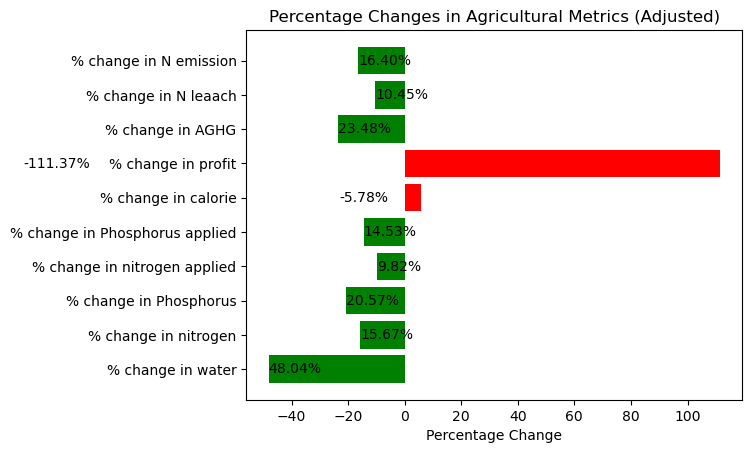

In [23]:
# Group by State and sum all numeric columns
grouped_data = merged_results_df.groupby(['State']).sum(numeric_only=True).reset_index()

# Percentage change calculations
grouped_data['% change in water'] = 100 * (grouped_data['Original water'] - grouped_data['Optimized water']) / grouped_data['Original water']
grouped_data['% change in nitrogen'] = 100 * (grouped_data['Original Total N surplus'] - grouped_data['Optimized Total N surplus']) / grouped_data['Original Total N surplus']
grouped_data['% change in Phosphorus'] = 100 * (grouped_data['Original Total P surplus'] - grouped_data['Optimized Total P surplus']) / grouped_data['Original Total P surplus']
grouped_data['% change in nitrogen applied'] = 100 * (grouped_data['Original Total N Applied'] - grouped_data['Optimized Total N Applied']) / grouped_data['Original Total N Applied']
grouped_data['% change in Phosphorus applied'] = 100 * (grouped_data['Original Total P Applied'] - grouped_data['Optimized Total P Applied']) / grouped_data['Original Total P Applied']
grouped_data['% change in calorie'] = 100 * (grouped_data['Original Calorie'] - grouped_data['Optimized Calorie']) / grouped_data['Original Calorie']
grouped_data['% change in profit'] = 100 * (grouped_data['Original profit'] - grouped_data['Optimized profit']) / grouped_data['Original profit']
grouped_data['% change in AGHG'] = 100 * (grouped_data['Original AGHG'] - grouped_data['Optimized AGHG']) / grouped_data['Original AGHG']
grouped_data['% change in N emission'] = 100 * (grouped_data['Original N_emission'] - grouped_data['Optimized N_emission']) / grouped_data['Original N_emission']
grouped_data['% change in N leaach'] = 100 * (grouped_data['Original N_leach'] - grouped_data['Optimized N_leach']) / grouped_data['Original N_leach']

# Total values and total percentage changes
total_data = merged_results_df.sum(numeric_only=True)
total_data['% change in water'] = 100 * (total_data['Original water'] - total_data['Optimized water']) / total_data['Original water']
total_data['% change in nitrogen'] = 100 * (total_data['Original Total N surplus'] - total_data['Optimized Total N surplus']) / total_data['Original Total N surplus']
total_data['% change in Phosphorus'] = 100 * (total_data['Original Total P surplus'] - total_data['Optimized Total P surplus']) / total_data['Original Total P surplus']
total_data['% change in nitrogen applied'] = 100 * (total_data['Original Total N Applied'] - total_data['Optimized Total N Applied']) / total_data['Original Total N Applied']
total_data['% change in Phosphorus applied'] = 100 * (total_data['Original Total P Applied'] - total_data['Optimized Total P Applied']) / total_data['Original Total P Applied']
total_data['% change in calorie'] = 100 * (total_data['Original Calorie'] - total_data['Optimized Calorie']) / total_data['Original Calorie']
total_data['% change in profit'] = 100 * (total_data['Original profit'] - total_data['Optimized profit']) / total_data['Original profit']
total_data['% change in AGHG'] = 100 * (total_data['Original AGHG'] - total_data['Optimized AGHG']) / total_data['Original AGHG']
total_data['% change in N emission'] = 100 * (total_data['Original N_emission'] - total_data['Optimized N_emission']) / total_data['Original N_emission']
total_data['% change in N leaach'] = 100 * (total_data['Original N_leach'] - total_data['Optimized N_leach']) / total_data['Original N_leach']

# Extracting the data for plotting directly from the total_data calculation results
percentage_changes = total_data[['% change in water', '% change in nitrogen', '% change in Phosphorus', 
            '% change in nitrogen applied', '% change in Phosphorus applied', 
            '% change in calorie', '% change in profit', '% change in AGHG','% change in N leaach','% change in N emission']]

# Converting Series to a dictionary for easier manipulation
percentage_changes_dict = percentage_changes.to_dict()

# Convert negative values to positive for plotting on the right side and determine color based on sign
values = [abs(value) for value in percentage_changes_dict.values()]
categories = list(percentage_changes_dict.keys())
colors = ['green' if value >= 0 else 'red' for value in percentage_changes_dict.values()]
# Adjusting the plot logic based on the new requirement:
# Positive values should be plotted on the negative side of the X-axis and vice versa.

# Determine the side of the bar based on the sign of the original value, reversing the logic
values_adjusted = [-abs(value) if value >= 0 else abs(value) for value in percentage_changes_dict.values()]

# Plotting with the adjusted logic
fig, ax = plt.subplots()
ax.barh(categories, values_adjusted, color=colors)
ax.set_xlabel('Percentage Change')
ax.set_title('Percentage Changes in Agricultural Metrics (Adjusted)')

# Annotating the bars with the actual percentage change values
for index, value in enumerate(percentage_changes_dict.values()):
    if value >= 0:
        ax.text(-value, index, f"{value:.2f}%", va='center', ha='left')
    else:
        ax.text(value, index, f"{value:.2f}%", va='center', ha='right')

plt.show()


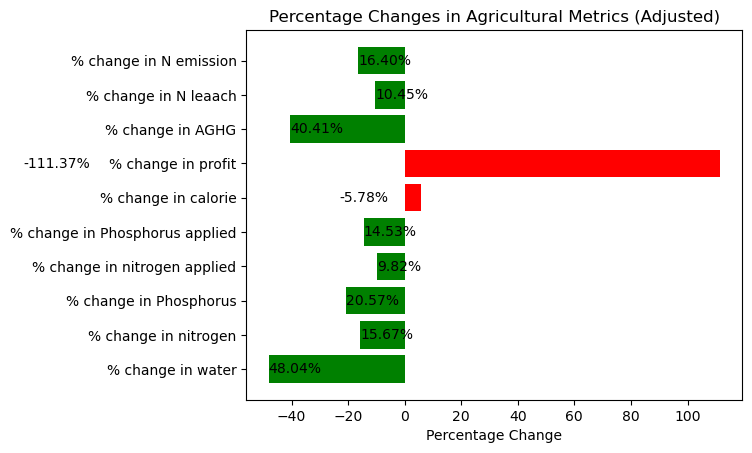

In [14]:
# Group by State and sum all numeric columns
grouped_data = merged_results_df.groupby(['State']).sum(numeric_only=True).reset_index()

# Percentage change calculations
grouped_data['% change in water'] = 100 * (grouped_data['Original water'] - grouped_data['Optimized water']) / grouped_data['Original water']
grouped_data['% change in nitrogen'] = 100 * (grouped_data['Original Total N surplus'] - grouped_data['Optimized Total N surplus']) / grouped_data['Original Total N surplus']
grouped_data['% change in Phosphorus'] = 100 * (grouped_data['Original Total P surplus'] - grouped_data['Optimized Total P surplus']) / grouped_data['Original Total P surplus']
grouped_data['% change in nitrogen applied'] = 100 * (grouped_data['Original Total N Applied'] - grouped_data['Optimized Total N Applied']) / grouped_data['Original Total N Applied']
grouped_data['% change in Phosphorus applied'] = 100 * (grouped_data['Original Total P Applied'] - grouped_data['Optimized Total P Applied']) / grouped_data['Original Total P Applied']
grouped_data['% change in calorie'] = 100 * (grouped_data['Original Calorie'] - grouped_data['Optimized Calorie']) / grouped_data['Original Calorie']
grouped_data['% change in profit'] = 100 * (grouped_data['Original profit'] - grouped_data['Optimized profit']) / grouped_data['Original profit']
grouped_data['% change in AGHG'] = 100 * (grouped_data['Original AGHG'] - grouped_data['Optimized AGHG']) / grouped_data['Original AGHG']
grouped_data['% change in N emission'] = 100 * (grouped_data['Original N_emission'] - grouped_data['Optimized N_emission']) / grouped_data['Original N_emission']
grouped_data['% change in N leaach'] = 100 * (grouped_data['Original N_leach'] - grouped_data['Optimized N_leach']) / grouped_data['Original N_leach']

# Total values and total percentage changes
total_data = merged_results_df.sum(numeric_only=True)
total_data['% change in water'] = 100 * (total_data['Original water'] - total_data['Optimized water']) / total_data['Original water']
total_data['% change in nitrogen'] = 100 * (total_data['Original Total N surplus'] - total_data['Optimized Total N surplus']) / total_data['Original Total N surplus']
total_data['% change in Phosphorus'] = 100 * (total_data['Original Total P surplus'] - total_data['Optimized Total P surplus']) / total_data['Original Total P surplus']
total_data['% change in nitrogen applied'] = 100 * (total_data['Original Total N Applied'] - total_data['Optimized Total N Applied']) / total_data['Original Total N Applied']
total_data['% change in Phosphorus applied'] = 100 * (total_data['Original Total P Applied'] - total_data['Optimized Total P Applied']) / total_data['Original Total P Applied']
total_data['% change in calorie'] = 100 * (total_data['Original Calorie'] - total_data['Optimized Calorie']) / total_data['Original Calorie']
total_data['% change in profit'] = 100 * (total_data['Original profit'] - total_data['Optimized profit']) / total_data['Original profit']
total_data['% change in AGHG'] = 100 * (total_data['Original AGHG'] - total_data['Optimized AGHG']) / total_data['Original AGHG']
total_data['% change in N emission'] = 100 * (total_data['Original N_emission'] - total_data['Optimized N_emission']) / total_data['Original N_emission']
total_data['% change in N leaach'] = 100 * (total_data['Original N_leach'] - total_data['Optimized N_leach']) / total_data['Original N_leach']

# Extracting the data for plotting directly from the total_data calculation results
percentage_changes = total_data[['% change in water', '% change in nitrogen', '% change in Phosphorus', 
            '% change in nitrogen applied', '% change in Phosphorus applied', 
            '% change in calorie', '% change in profit', '% change in AGHG','% change in N leaach','% change in N emission']]

# Converting Series to a dictionary for easier manipulation
percentage_changes_dict = percentage_changes.to_dict()

# Convert negative values to positive for plotting on the right side and determine color based on sign
values = [abs(value) for value in percentage_changes_dict.values()]
categories = list(percentage_changes_dict.keys())
colors = ['green' if value >= 0 else 'red' for value in percentage_changes_dict.values()]
# Adjusting the plot logic based on the new requirement:
# Positive values should be plotted on the negative side of the X-axis and vice versa.

# Determine the side of the bar based on the sign of the original value, reversing the logic
values_adjusted = [-abs(value) if value >= 0 else abs(value) for value in percentage_changes_dict.values()]

# Plotting with the adjusted logic
fig, ax = plt.subplots()
ax.barh(categories, values_adjusted, color=colors)
ax.set_xlabel('Percentage Change')
ax.set_title('Percentage Changes in Agricultural Metrics (Adjusted)')

# Annotating the bars with the actual percentage change values
for index, value in enumerate(percentage_changes_dict.values()):
    if value >= 0:
        ax.text(-value, index, f"{value:.2f}%", va='center', ha='left')
    else:
        ax.text(value, index, f"{value:.2f}%", va='center', ha='right')

plt.show()


NameError: name 'df_comp' is not defined

In [16]:
import pandas as pd
import pulp

# -------------------------------------------------------
# Load AGHG factor data (per‑kg CO2e for residue burning)
# -------------------------------------------------------
aghg_df = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\data\aghg_factor.csv")

# Constants
N2O_GWP = 273  # IPCC AR6: 1 kg N2O = 273 kg CO2-eq
# If your fn2o yields N2O-N, set USE_N2O_N=True to apply 44/28 conversion.
USE_N2O_N = False
MOLAR_RATIO_N2O = 44/28

# Build lookup tables
# NOTE: These per‑kg factors are **residue burning** intensities per kg of grain
rice_burn_CO2eq_perkg    = aghg_df.set_index('State')['Rice_CO2eq_perkg'].to_dict()
wheat_burn_CO2eq_perkg   = aghg_df.set_index('State')['Wheat_CO2eq_perkg'].to_dict()
maize_burn_CO2eq_perkg   = aghg_df.set_index('State')['Maize_CO2eq_perkg'].to_dict()
millets_burn_CO2eq_perkg = aghg_df.set_index('State')['Millets_CO2eq_perkg'].to_dict()
# CH4 from flooded rice (already CO2e per ha)
rice_ch4_per_ha          = aghg_df.set_index('State')['rice_ch4_co2_eq_per_ha'].to_dict()


def calculate_aghg_breakdown(area_dict):
    """
    area_dict: {(state, district, crop): area_ha}
    Uses:
      - Residue burning: per-kg CO2e * production_kg (production_kg = area_ha * yield_kg_per_ha)
      - Rice CH4: per-ha CO2e * area_ha
      - Soils N2O: fn2o * N_surplus (with optional N2O-N→N2O) * GWP
    Returns: (total_aghg_kgCO2e, components_dict)
    """
    components = {
        "Rice_burning_CO2eq":   0.0,
        "Rice_CH4_CO2eq":       0.0,
        "Wheat_burning_CO2eq":  0.0,
        "Maize_burning_CO2eq":  0.0,
        "Millets_burning_CO2eq":0.0,
        "Soils_N2O_CO2eq":      0.0
    }
    total_aghg = 0.0

    # ---------- residue burning + rice CH4 ----------
    for (s, d, c), area in area_dict.items():
        area = float(area or 0.0)
        if area <= 0:
            continue

        yld_kg_ha = float(yield_data.get((s, d, c), 0.0))  # kg/ha
        prod_kg   = area * yld_kg_ha                       # kg grain
        rs = s.strip().lower()

        if c == 'rice':
            rice_burn = prod_kg * float(rice_burn_CO2eq_perkg.get(rs, 0.0))
            rice_ch4  = area    * float(rice_ch4_per_ha.get(rs, 0.0))
            components["Rice_burning_CO2eq"] += rice_burn
            components["Rice_CH4_CO2eq"]     += rice_ch4
            total_aghg += rice_burn + rice_ch4

        elif c == 'wheat':
            wheat_burn = prod_kg * float(wheat_burn_CO2eq_perkg.get(rs, 0.0))
            components["Wheat_burning_CO2eq"] += wheat_burn
            total_aghg += wheat_burn

        elif c == 'maize':
            maize_burn = prod_kg * float(maize_burn_CO2eq_perkg.get(rs, 0.0))
            components["Maize_burning_CO2eq"] += maize_burn
            total_aghg += maize_burn

        elif c in ['bajra', 'jowar', 'ragi']:
            millets_burn = prod_kg * float(millets_burn_CO2eq_perkg.get(rs, 0.0))
            components["Millets_burning_CO2eq"] += millets_burn
            total_aghg += millets_burn

    # ---------- soils N2O (from N surplus) ----------
    # N_surplus (kg N) = area_ha * N_applied_rate(kg/ha) - production_kg * N_removed_rate_perkg(kg N/kg grain)
    n2o_term = 0.0
    for (s, d, c), area in area_dict.items():
        area = float(area or 0.0)
        if area <= 0:
            continue

        yld_kg_ha = float(yield_data.get((s, d, c), 0.0))
        prod_kg   = area * yld_kg_ha

        n_appl      = float(nitrogen_rate.get((s, d, c), 0.0))                 # kg N/ha
        n_rem_perkg = float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0))   # kg N/kg grain
        fn2o        = float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))  # fraction of N surplus

        n_surplus = area * n_appl - prod_kg * n_rem_perkg  # kg N
        n2o_from_nsur = n_surplus * fn2o                   # If fn2o is N2O or N2O-N depends on your coeff.
        if USE_N2O_N:
            n2o_from_nsur *= MOLAR_RATIO_N2O  # convert N2O-N -> N2O

        n2o_term += n2o_from_nsur

    soils_n2o_co2eq = n2o_term * N2O_GWP
    components["Soils_N2O_CO2eq"] += soils_n2o_co2eq
    total_aghg += soils_n2o_co2eq

    components["Total"] = total_aghg
    return total_aghg, components


# ================
# Run both cases
# ================
# 1) ORIGINAL (current_cereal_area already defined upstream)
orig_total,  orig_comp  = calculate_aghg_breakdown(current_cereal_area)

# 2) OPTIMIZED (pull areas from decision vars x)
optimized_area_dict = {(s, d, c): (pulp.value(x[s][d][c]) or 0.0)
                       for s in states for d in districts for c in cereals}
opt_total,   opt_comp   = calculate_aghg_breakdown(optimized_area_dict)

# ==========================
# Comparison DataFrame
# ==========================
rows = list(orig_comp.keys())  # includes "Total" last
df_comp = pd.DataFrame({
    "Component": rows,
    "Original_kgCO2e": [orig_comp[k] for k in rows],
    "Optimized_kgCO2e":[opt_comp[k]  for k in rows]
})
df_comp["Reduction_kgCO2e"] = df_comp["Original_kgCO2e"] - df_comp["Optimized_kgCO2e"]
df_comp["Reduction_%"] = df_comp.apply(
    lambda r: 100.0 * r["Reduction_kgCO2e"] / r["Original_kgCO2e"] if r["Original_kgCO2e"] else 0.0,
    axis=1
)
df_comp["Share_of_Orig_%"] = df_comp.apply(
    lambda r: 100.0 * r["Original_kgCO2e"] / orig_total if orig_total else 0.0,
    axis=1
)

pd.options.display.float_format = '{:,.2f}'.format
print(df_comp)

print("\n✅ Totals match check")
print("Original total (from breakdown):", orig_total)
print("Optimized total (from breakdown):", opt_total)


               Component    Original_kgCO2e   Optimized_kgCO2e  \
0     Rice_burning_CO2eq  49,677,111,287.43  38,714,425,794.97   
1         Rice_CH4_CO2eq  87,140,962,801.86  48,868,691,504.99   
2    Wheat_burning_CO2eq               0.00               0.00   
3    Maize_burning_CO2eq   4,267,387,780.92  12,347,332,866.68   
4  Millets_burning_CO2eq   2,541,116,715.40   3,533,323,476.07   
5        Soils_N2O_CO2eq  49,594,610,020.06  40,666,887,775.26   
6                  Total 193,221,188,605.66 144,130,661,417.96   

   Reduction_kgCO2e  Reduction_%  Share_of_Orig_%  
0 10,962,685,492.46        22.07            25.71  
1 38,272,271,296.86        43.92            45.10  
2              0.00         0.00             0.00  
3 -8,079,945,085.76      -189.34             2.21  
4   -992,206,760.67       -39.05             1.32  
5  8,927,722,244.80        18.00            25.67  
6 49,090,527,187.70        25.41           100.00  

✅ Totals match check
Original total (from breakdown): 

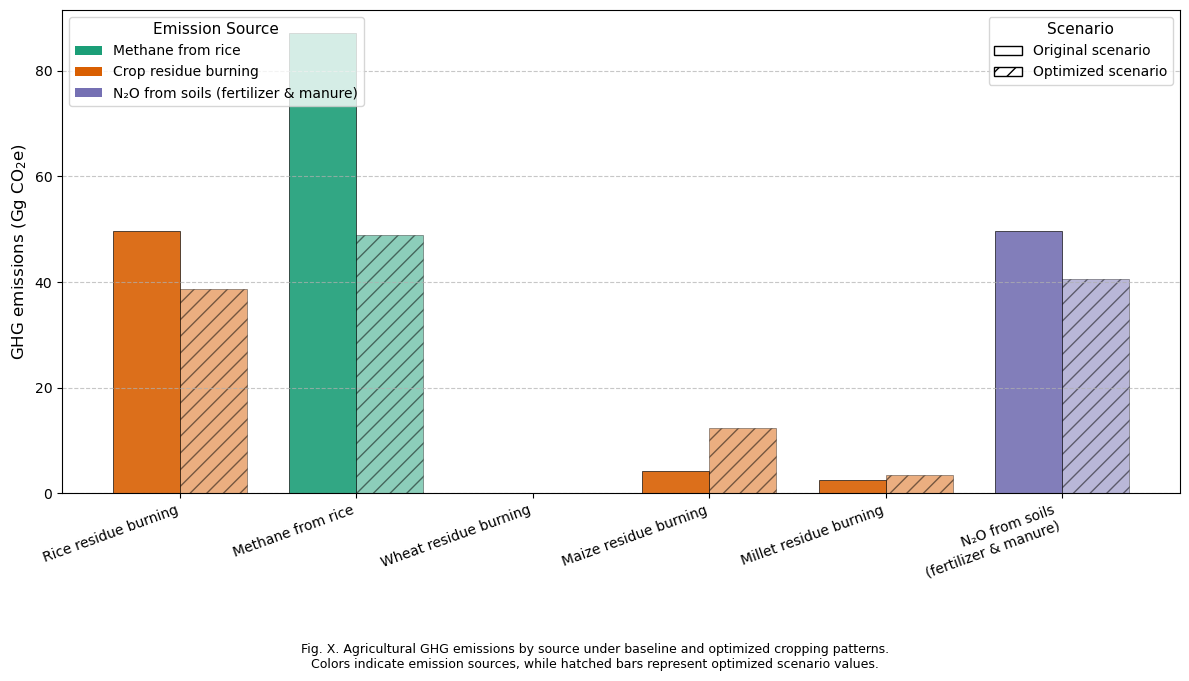

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Drop 'Total' row for plotting
df_plot = df_comp[df_comp["Component"] != "Total"].copy()

# Map each component to an emission source and color
source_colors = {
    "Rice_burning_CO2eq":     ("Crop residue burning", "#d95f02"),
    "Wheat_burning_CO2eq":    ("Crop residue burning", "#d95f02"),
    "Maize_burning_CO2eq":    ("Crop residue burning", "#d95f02"),
    "Millets_burning_CO2eq":  ("Crop residue burning", "#d95f02"),
    "Rice_CH4_CO2eq":         ("Methane from rice", "#1b9e77"),
    "Soils_N2O_CO2eq":        ("N₂O from soils (fertilizer & manure)", "#7570b3")
}

df_plot["Source"] = df_plot["Component"].map(lambda c: source_colors[c][0])
df_plot["Color"] = df_plot["Component"].map(lambda c: source_colors[c][1])

# Prepare data
components = df_plot["Component"].tolist()
orig_vals = df_plot["Original_kgCO2e"].values / 1e9  # to Gg
opt_vals  = df_plot["Optimized_kgCO2e"].values / 1e9
colors = df_plot["Color"].tolist()

x = np.arange(len(components))
width = 0.38

# Figure
fig, ax = plt.subplots(figsize=(12, 6))

# Original bars
bars1 = ax.bar(x - width/2, orig_vals, width, label='Original scenario',
               color=colors, alpha=0.9, edgecolor='black', linewidth=0.5)

# Optimized bars (hatched)
bars2 = ax.bar(x + width/2, opt_vals, width, label='Optimized scenario',
               color=colors, alpha=0.5, edgecolor='black', linewidth=0.5, hatch='//')

# Axis labels & ticks
ax.set_ylabel("GHG emissions (Gg CO$_2$e)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(components, rotation=30, ha='right', fontsize=10)
ax.tick_params(axis='y', labelsize=10)

# Gridlines
ax.grid(axis='y', linestyle='--', alpha=0.7)
# Custom display names for x-axis
label_map = {
    "Rice_burning_CO2eq": "Rice residue burning",
    "Rice_CH4_CO2eq": "Methane from rice",
    "Wheat_burning_CO2eq": "Wheat residue burning",
    "Maize_burning_CO2eq": "Maize residue burning",
    "Millets_burning_CO2eq": "Millet residue burning",
    "Soils_N2O_CO2eq": "N₂O from soils\n(fertilizer & manure)"
}

# Apply readable labels
xtick_labels = [label_map.get(c, c) for c in components]

# In plotting section:
ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=20, ha='right', fontsize=10)

# Legend: First for emission sources, then for scenario type
source_legend = [
    Patch(facecolor="#1b9e77", label="Methane from rice"),
    Patch(facecolor="#d95f02", label="Crop residue burning"),
    Patch(facecolor="#7570b3", label="N₂O from soils (fertilizer & manure)")
]
scenario_legend = [
    Patch(facecolor='white', edgecolor='black', label='Original scenario'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='Optimized scenario')
]

# Combine legends
first_legend = ax.legend(handles=source_legend, title="Emission Source",
                         fontsize=10, title_fontsize=11, loc='upper left')
ax.add_artist(first_legend)  # Keep first legend on plot
ax.legend(handles=scenario_legend, title="Scenario",
          fontsize=10, title_fontsize=11, loc='upper right')

# Caption-like text
fig.text(0.5, -0.08,
         "Fig. X. Agricultural GHG emissions by source under baseline and optimized cropping patterns.\n"
         "Colors indicate emission sources, while hatched bars represent optimized scenario values.",
         ha='center', va='top', fontsize=9)
save_path = r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\fig\GHG_components_comparison_water_kharif.png"
#os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=600, bbox_inches="tight")
plt.tight_layout()
plt.show()
